1st clone repo to working directory

In [90]:
import git

repo = git.Repo.clone_from(
    "https://github.com/frankmollard/fuzzyfier",
    "./fuzzyfier"
)

In [1]:
import sys

2nd append path to environmental variables

In [2]:
sys.path.append("./fuzzyfier/src")

In [18]:
import numpy as np 
from matplotlib import pyplot as plt
from fuzzyfication import fuzzyfication

> In this norebook, we show how a simple stock-picking strategy can be developed using fuzzy logic. This is a simple example that should not be implemented as-is in practice, since more complex conditions are typically used when making buy or sell decisions. 

# Simulation

Let's assume a portfolio consisting of two stocks. 

share1 and share2 represent the market values in $ of the two shares

In [201]:
share1 = np.array([51, 48, 46, 47, 46])
share2 = np.array([30, 30, 31, 32, 32])

In [202]:
s1Growth = np.diff(share1) / share1[:-1]
s1Growth

array([-0.05882353, -0.04166667,  0.02173913, -0.0212766 ])

In [203]:
s2Growth = np.diff(share2) / share2[:-1]
s2Growth

array([0.        , 0.03333333, 0.03225806, 0.        ])

stock and marketTrend are the experts conditions

In [204]:
stock = {"small": 0, "middle": 100, "high": 1000}
marketTrend= {"negative": -2, "stagnation": 0, "positive": 2}

share1Stock and share2Stock represent the initial number of stocks

In [210]:
share1Stock = 100
share2Stock = 100

maxBuy is the maximum number of stocks to buy

In [219]:
maxBuy = 1000

## Value of Portfolio

The Value is calculated for n Stocks by 

$$ \sum_{i=1}^{n} No~of~Stock_i \cdot price_i $$

additionally the earnings through sales and purchases are taken into account.

In [212]:
portfolioValue = []

for i in range(len(share1)):
    portfolioValue.append(share1[i]*share1Stock + share2[i]*share1Stock)

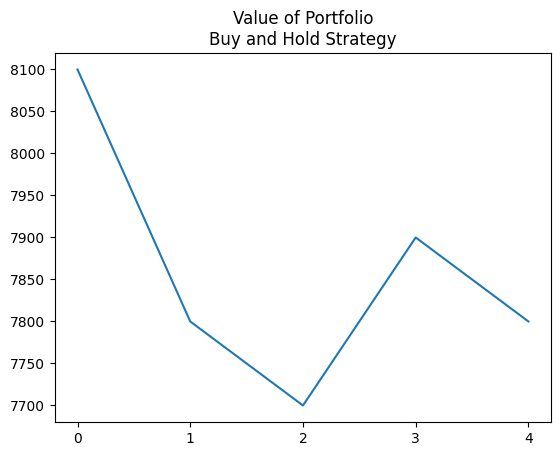

In [213]:
plt.title("Value of Portfolio\nBuy and Hold Strategy")
plt.plot(portfolioValue)
plt.xticks([0, 1, 2, 3, 4])
plt.show()

The following function reacts to the market trends usinf fuzzy and calculates the development of the number of shares, the sales, purchases, and the value of the portfolio.

In [214]:
def portfolioTrend(marketValues, growth, startStock, maxBuy):
    noOfShares = [startStock]
    sales = []
    purchases = []
    assetValue = [startStock*marketValues[0]]
    
    for i in range(len(growth)):
    
        fS1=fuzzyfication(stock, startStock)
        fMT1=fuzzyfication(marketTrend, growth[i])
    
        c1 = np.min([fS1.fuzzy()["small"], fMT1.fuzzy()["negative"]]) #buy
        c2 = np.min([fS1.fuzzy()["high"], fMT1.fuzzy()["positive"]]) #sell
        c3 = np.min([np.max([fS1.fuzzy()["middle"], fS1.fuzzy()["high"]]), fMT1.fuzzy()["stagnation"]]) #hold
        
        activations = {"Buy": c1, "Sell": c2, "Hold": c3}
        decisions = {k: int(np.round(v*maxBuy)) if k == "Buy" else int(np.round(v*startStock)) for k, v in activations.items()}
    
        startStock = startStock + decisions["Buy"]
        purchase = decisions["Buy"] * marketValues[i+1]
        purchases.append(purchase)
        
        avtivationsHold = {k: v for k, v in activations.items() if k not in ["Buy"]}
        avtivationsHold["Hold"] = 1 - avtivationsHold["Hold"]
        
        resultingValuesSell = list({k: v for k, v in decisions.items() if k not in ["Buy"]}.values())
        resultingValuesSell[1] = startStock - resultingValuesSell[1]
        
        sell = fS1.defuzzification(avtivationsHold, resultingValuesSell)
    
        startStock = startStock - sell[0]
        revenue = sell[0] * marketValues[i+1]
        sales.append(revenue)
    
        noOfShares.append(startStock)
        assetValue.append(startStock * marketValues[i+1])
        
    return {"NoShares": np.array(noOfShares), "Sales": np.array(sales), "Purchases": np.array(purchases), "AssetValue": np.array(assetValue)}

In [215]:
share1Heistory = portfolioTrend(share1, s1Growth, 100, 1000)

In [216]:
share2Heistory = portfolioTrend(share2, s2Growth, 100, 1000)

In [217]:
portfolioValue = share1Heistory["AssetValue"] + share2Heistory["AssetValue"]

earnings = share1Heistory["Purchases"] - share2Heistory["Purchases"] + share1Heistory["Sales"] + share2Heistory["Sales"]
earnings = earnings.tolist()
earnings.insert(0, 0)

print("Portfolio value + earnings", portfolioValue + earnings)

Portfolio value + earnings [8100 7800 9494 7554 8132]


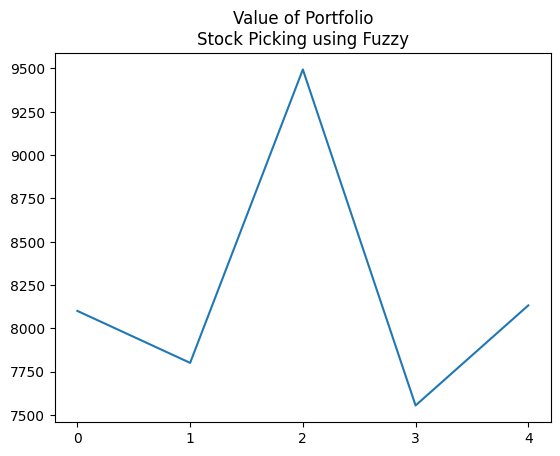

In [220]:
plt.title("Value of Portfolio\nStock Picking using Fuzzy")
plt.plot(portfolioValue + earnings)
plt.xticks([0, 1, 2, 3, 4])
plt.show()

As can be seen, the performance of the portfolio—which consists of the portfolio’s value and the gains earned through purchases and sales - is significantly better. While the “Buy and Hold” strategy resulted in losses (compared to the starting point), the “Fuzzy” strategy generated gains along the way and ultimately at least maintained the value.

Note that with the buy-and-hold strategy, the portfolio’s value was also increased by the profits; however, since no transactions took place, these profits were zero.